# Understanding data

This notebook is dedicated to understanding the data provided.

In [1]:
from pathlib import Path

data_dir = Path('../input/jane-street-real-time-market-data-forecasting')

## Step 1: Loading training

Let's spend sometime understanding how the training set is structured.

In [2]:
import pandas as pd

for partition in range(0, 10):
    location = data_dir / f'train.parquet/partition_id={partition}/part-0.parquet'
    df = pd.read_parquet(location, columns=['date_id'])
    min_date, max_date = df['date_id'].min(), df['date_id'].max()
    print(f"Partition {partition}:")
    print(f"\tMin = {min_date}")
    print(f"\tMax = {max_date}")
    print('=' * 120)

Partition 0:
	Min = 0
	Max = 169
Partition 1:
	Min = 170
	Max = 339
Partition 2:
	Min = 340
	Max = 509
Partition 3:
	Min = 510
	Max = 679
Partition 4:
	Min = 680
	Max = 849
Partition 5:
	Min = 850
	Max = 1019
Partition 6:
	Min = 1020
	Max = 1189
Partition 7:
	Min = 1190
	Max = 1359
Partition 8:
	Min = 1360
	Max = 1529
Partition 9:
	Min = 1530
	Max = 1698


These results indicate that there is no overlap in dates between partitions, and that they follow a chronological ordering. 

Let's then investigate some of the details only for partition 0.

In [3]:
train_0 = pd.read_parquet(data_dir / 'train.parquet/partition_id=0/part-0.parquet')

train_0.sort_values(by=['date_id', 'time_id'], inplace=True)

## Step 2: Quick overlook on `responder_6`

Let's see if there is any considerable shift in the responder as a function of date.

In [4]:
daily = train_0.groupby('date_id')
r6_daily_avg = daily['responder_6'].mean()
r6_daily_std = daily['responder_6'].std()

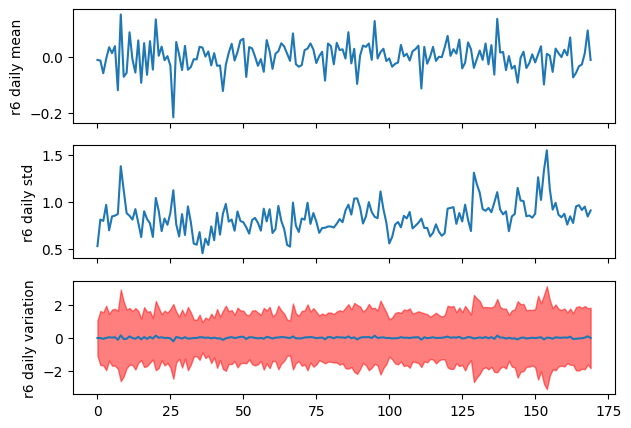

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, sharex='col', figsize=(7, 5))
axes[0].set_ylabel('r6 daily mean')
axes[1].set_ylabel('r6 daily std')
axes[2].set_ylabel('r6 daily variation')

axes[0].plot(r6_daily_avg)
axes[1].plot(r6_daily_std)
_ = axes[-1].fill_between(range(len(r6_daily_avg)),
                          r6_daily_avg + 2 * r6_daily_std,
                          r6_daily_avg - 2 * r6_daily_std,
                          color='red',
                          alpha=0.5)
_ = axes[-1].plot(r6_daily_avg)

## Step 3: Quick check on features

Now, let's take a look at some other statistics

In [6]:
# assuming df is partition 0
print("Dates:", train_0["date_id"].nunique())
print("Time per date:")
print(train_0.groupby("date_id")["time_id"].nunique().describe())

print("Symbols per timestep:")
print(train_0.groupby(["date_id","time_id"])["symbol_id"].nunique().describe())

print("Feature stats (first 10 features):")
print(train_0[[f"feature_{i:02d}" for i in range(10)]].describe())

print("Target stats:")
print(train_0["responder_6"].describe())

print("Weight stats:")
print(train_0["weight"].describe())

Dates: 170
Time per date:
count    170.0
mean     849.0
std        0.0
min      849.0
25%      849.0
50%      849.0
75%      849.0
max      849.0
Name: time_id, dtype: float64
Symbols per timestep:
count    144330.000000
mean         13.470588
std           3.252479
min           4.000000
25%          11.000000
50%          13.500000
75%          16.000000
max          20.000000
Name: symbol_id, dtype: float64
Feature stats (first 10 features):
       feature_00  feature_01  feature_02  feature_03  feature_04  \
count         0.0         0.0         0.0         0.0         0.0   
mean          NaN         NaN         NaN         NaN         NaN   
std           NaN         NaN         NaN         NaN         NaN   
min           NaN         NaN         NaN         NaN         NaN   
25%           NaN         NaN         NaN         NaN         NaN   
50%           NaN         NaN         NaN         NaN         NaN   
75%           NaN         NaN         NaN         NaN         NaN   

It appears some features are all `NaN`. Let's get a better understanding of how often we have missing information.

In [7]:
# list of all feature columns
feature_cols = [f"feature_{i:02d}" for i in range(79)]

# compute fraction of NaNs per feature
nan_fraction_per_feature = train_0[feature_cols].isna().mean()

# display nicely
for feature, frac in nan_fraction_per_feature.items():
    print(f"{feature}: {frac*100:.1f}%")

feature_00: 100.0%
feature_01: 100.0%
feature_02: 100.0%
feature_03: 100.0%
feature_04: 100.0%
feature_05: 0.0%
feature_06: 0.0%
feature_07: 0.0%
feature_08: 0.9%
feature_09: 0.0%
feature_10: 0.0%
feature_11: 0.0%
feature_12: 0.0%
feature_13: 0.0%
feature_14: 0.0%
feature_15: 2.8%
feature_16: 0.0%
feature_17: 0.5%
feature_18: 0.0%
feature_19: 0.0%
feature_20: 0.0%
feature_21: 100.0%
feature_22: 0.0%
feature_23: 0.0%
feature_24: 0.0%
feature_25: 0.0%
feature_26: 100.0%
feature_27: 100.0%
feature_28: 0.0%
feature_29: 0.0%
feature_30: 0.0%
feature_31: 100.0%
feature_32: 1.1%
feature_33: 1.1%
feature_34: 0.0%
feature_35: 0.0%
feature_36: 0.0%
feature_37: 0.0%
feature_38: 0.0%
feature_39: 16.7%
feature_40: 2.0%
feature_41: 5.0%
feature_42: 16.7%
feature_43: 2.0%
feature_44: 5.0%
feature_45: 8.6%
feature_46: 8.6%
feature_47: 0.0%
feature_48: 0.0%
feature_49: 0.0%
feature_50: 15.1%
feature_51: 0.1%
feature_52: 3.3%
feature_53: 15.1%
feature_54: 0.1%
feature_55: 3.3%
feature_56: 0.0%
feature_5

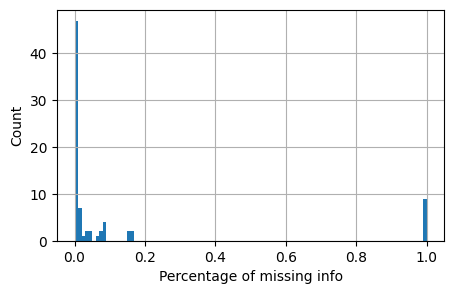

In [30]:
import numpy as np

axes = nan_fraction_per_feature.hist(bins=np.arange(0., 1.01, 0.01).tolist())
axes.set_ylabel('Count')
axes.set_xlabel('Percentage of missing info')

fig = axes.get_figure()
fig.set_size_inches(5, 3)

As we can see, there are a number of features with missing information. In particular, they appear to be in one of four categories:
- fully missing (can be discarded)
- ~15% of entries missing (needs imputation and possibly a missing-value flag)
- ~8% of entries missing (needs imputation and possibly missing-value flag)
- <5% missing entries (needs imputation, likely ok without missing-value flag)

## Step 4: Understand responder dynamics based on symbol

## Step 5: Explore correlations between responders